In [1]:
# 2026-03-23: first mandatory cmlykke kladde
# We have a regression problem and a classification problem.
# this project is focues on the classification problem.

# Classification problem:

#We assume that cars from different regions will have different
# characteristics, therefore we want to ask the question:

#Can we predict the origin of a car based on its the
# following attributes: acceleration, weight, horsepower,
# displacement, cylinders, MPG.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [3]:
# Load data
df = pd.read_csv('../../data/cars.csv')
df.head()
#print(df.count())


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
# Data exploration and cleaning
# Check for missing values
#print(df.isnull().sum())

# Horsepower has '?' as missing values
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['horsepower'])
print(df.count())


mpg             392
cylinders       392
displacement    392
horsepower      392
weight          392
acceleration    392
model year      392
origin          392
car name        392
dtype: int64


In [5]:
# Define features and target
features = ['acceleration', 'weight', 'horsepower', 'displacement', 'cylinders', 'mpg']
X = df[features]
y = df['origin']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# take a look at the split data:
print(X_train.count())
print(X_test.count())
print(y_train.count())
print(y_test.count())

acceleration    313
weight          313
horsepower      313
displacement    313
cylinders       313
mpg             313
dtype: int64
acceleration    79
weight          79
horsepower      79
displacement    79
cylinders       79
mpg             79
dtype: int64
313
79


In [7]:
# Single Decision Tree
# Using max_depth=5 to prevent overfitting and make it more manageable for a paper.
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))



Decision Tree Accuracy: 0.7974683544303798

Classification Report:
               precision    recall  f1-score   support

           1       0.82      0.95      0.88        43
           2       0.74      0.70      0.72        20
           3       0.80      0.50      0.62        16

    accuracy                           0.80        79
   macro avg       0.79      0.72      0.74        79
weighted avg       0.79      0.80      0.79        79



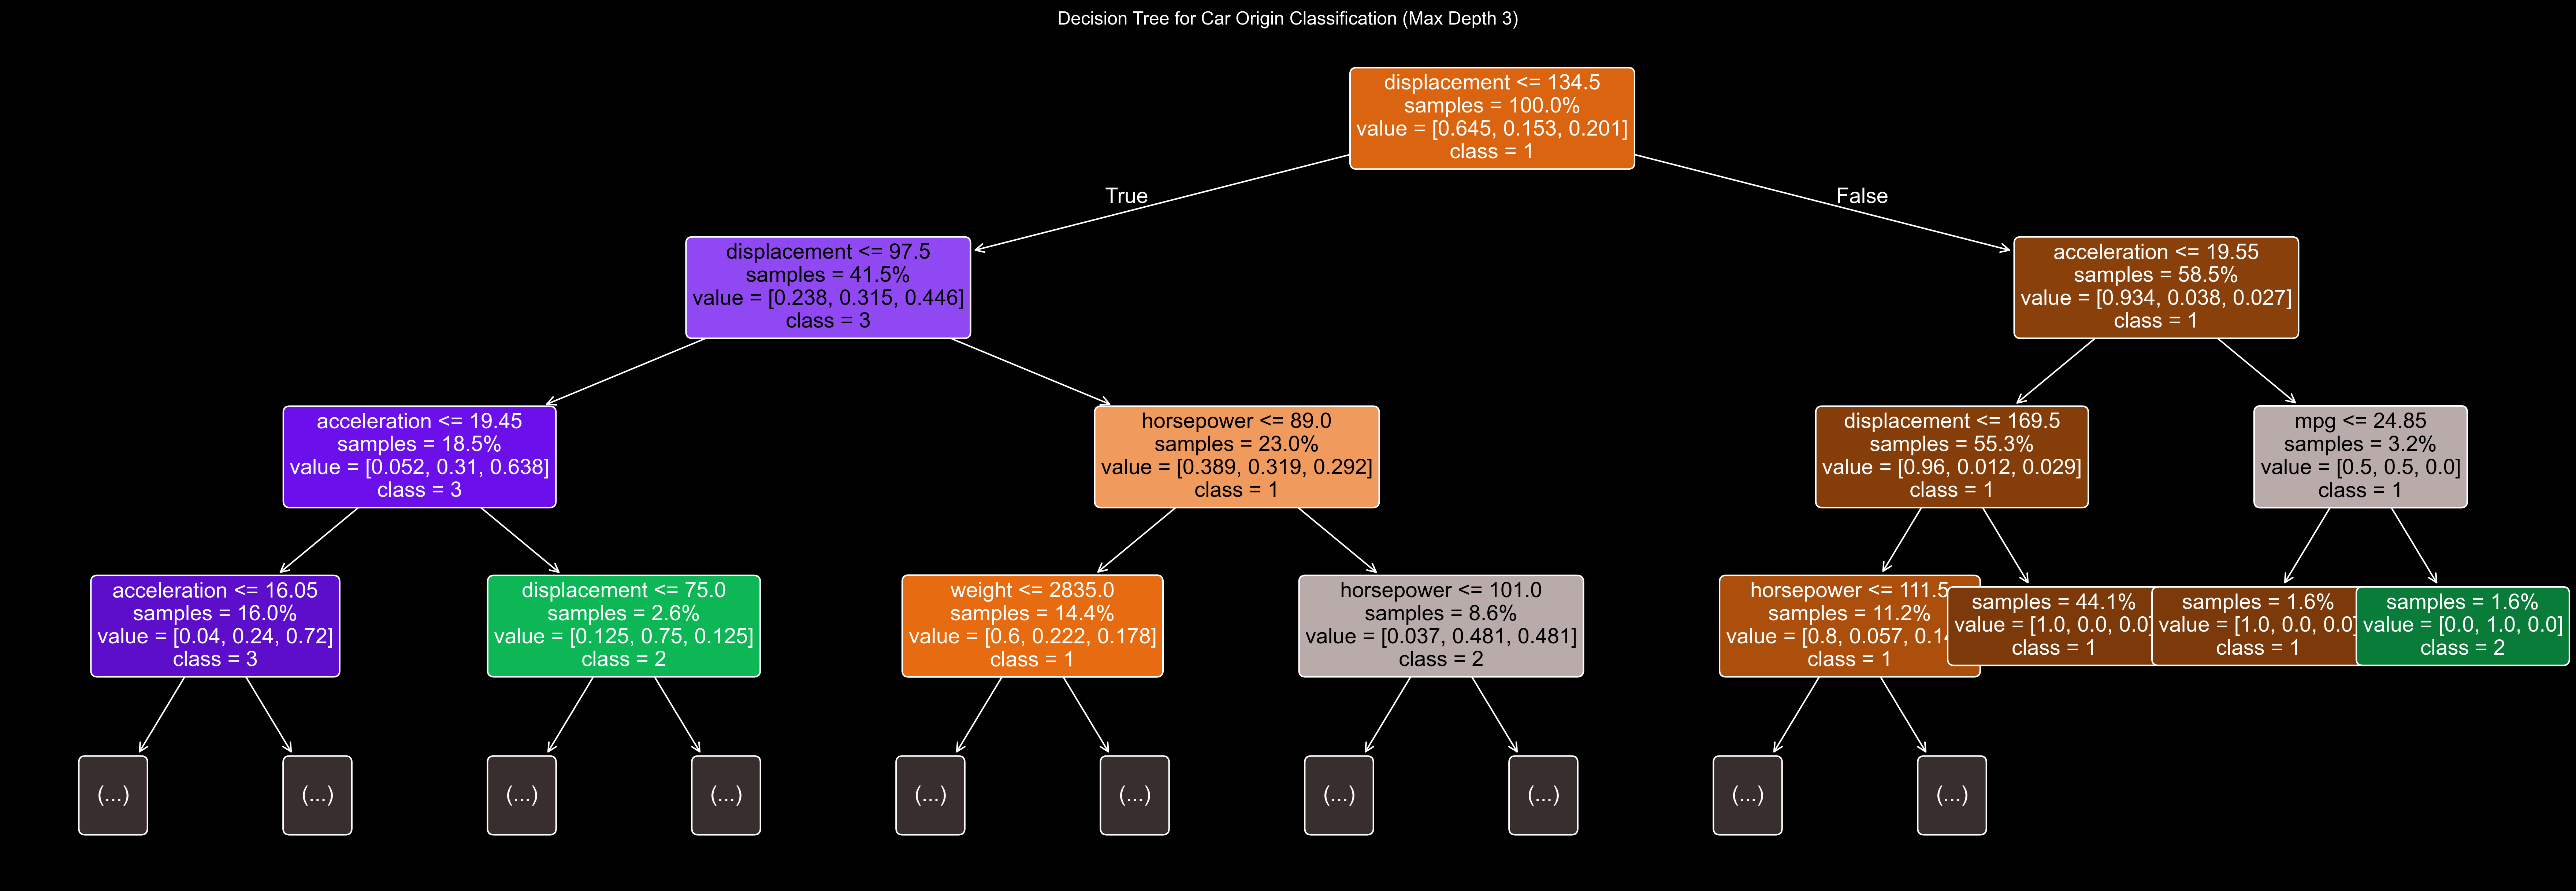

In [18]:

# %%
# Visualize Decision Tree
# To keep the tree readable for a paper, we limit the depth
plt.figure(figsize=(30, 10), dpi=300) # Increased figure size more to reduce overlap at 3rd level nodes
annotations = plot_tree(dt_model,
          feature_names=features,
          class_names=[str(c) for c in dt_model.classes_],
          filled=True,
          rounded=True,
          fontsize=14, # Slightly larger font for better readability with larger figure size
          impurity=False, # Removed impurity to reduce clutter and make text more readable
          proportion=True, # Show proportions to make numbers smaller and cleaner
          max_depth=3) # Limit depth for visualization

# Darken the background of nodes to improve text readability
import colorsys
for ann in annotations:
    bbox_patch = ann.get_bbox_patch()
    if bbox_patch is not None:
        fc = bbox_patch.get_facecolor()
        r, g, b, a = fc
        h, l, s = colorsys.rgb_to_hls(r, g, b)
        # Darken the lightness (l) by a significant amount (e.g., 30%)
        # and increase saturation (s) to keep it colorful
        new_l = max(0, l - 0.3)
        new_s = min(1, s + 0.1)
        new_r, new_g, new_b = colorsys.hls_to_rgb(h, new_l, new_s)
        bbox_patch.set_facecolor((new_r, new_g, new_b, a))
        
        # Adjust text color for contrast
        if new_l < 0.5:
            ann.set_color('white')
        else:
            ann.set_color('black')

plt.title("Decision Tree for Car Origin Classification (Max Depth 3)")
plt.savefig("decision_tree.png", bbox_inches='tight', pad_inches=0.1)
plt.show()

In [9]:


# %%
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.759493670886076

Classification Report:
               precision    recall  f1-score   support

           1       0.83      0.91      0.87        43
           2       0.62      0.65      0.63        20
           3       0.73      0.50      0.59        16

    accuracy                           0.76        79
   macro avg       0.73      0.69      0.70        79
weighted avg       0.76      0.76      0.75        79



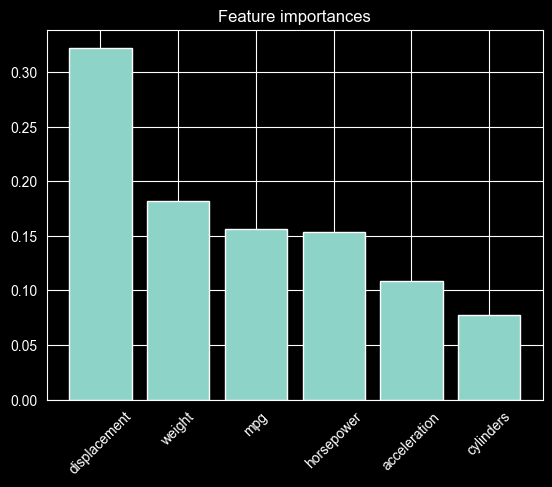

In [10]:
# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.show()


In [11]:
# feature importance asa a table:
# Create a DataFrame with features and their importance scores
importance_table = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

# Sort by importance (descending)
importance_table = importance_table.sort_values(by='Importance', ascending=False)

print(importance_table)

        Feature  Importance
3  displacement    0.322400
1        weight    0.181861
5           mpg    0.156178
2    horsepower    0.153274
0  acceleration    0.108909
4     cylinders    0.077378
